# Lab 6: Association Rule Mining with Apriori and FP-Growth

**Name:** Rabi Gurung  
**Course:** Advanced Big Data and Data Mining (MSCS-634-B01)  
**Assignment:** Lab 6: Association Rule Mining with Apriori and FP-Growth


## Purpose

This notebook applies association rule mining to a public bakery transaction dataset. Each row records one item purchased in a transaction. The analysis prepares the transactions for basket mining, explores item frequency and co-occurrence, mines frequent itemsets with Apriori and FP-Growth, generates association rules, and compares the two algorithms.

The dataset used here is `BreadBasket_DMS.csv` from the public `prasertcbs/basic-dataset` GitHub repository. 


In [1]:
from collections import defaultdict
from itertools import combinations
from pathlib import Path
import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
DATA_URL = "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/BreadBasket_DMS.csv"
DATA_PATH = Path("BreadBasket_DMS.csv")


## Step 1: Data Preparation

The raw file has one row per item. To mine itemsets, the rows must be grouped into baskets by transaction ID. Duplicate item entries within the same transaction are removed because Apriori and FP-Growth need to know whether an item was present in a basket, not how many times it appeared in that basket.


In [2]:
if DATA_PATH.exists():
    raw = pd.read_csv(DATA_PATH)
else:
    raw = pd.read_csv(DATA_URL)
    raw.to_csv(DATA_PATH, index=False)

raw.head()


,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam


In [3]:
clean = raw.copy()
clean.columns = clean.columns.str.strip()
clean["Item"] = clean["Item"].astype(str).str.strip()
clean = clean.dropna(subset=["Transaction", "Item"])
clean = clean[clean["Item"].str.lower() != "none"]
clean["Transaction"] = clean["Transaction"].astype(int)

transactions = (
    clean.groupby("Transaction")["Item"]
    .apply(lambda items: sorted(set(items)))
    .reset_index(name="Items")
)
transactions["BasketSize"] = transactions["Items"].str.len()
transactions = transactions[transactions["BasketSize"] > 0].reset_index(drop=True)

transaction_count = len(transactions)
unique_items = sorted(clean["Item"].unique())

summary = pd.DataFrame(
    {
        "Measure": ["Raw item rows", "Transactions", "Unique items", "Average basket size", "Median basket size"],
        "Value": [
            len(raw),
            transaction_count,
            len(unique_items),
            round(transactions["BasketSize"].mean(), 2),
            transactions["BasketSize"].median(),
        ],
    }
)
summary


,Measure,Value
0,Raw item rows,21293.0
1,Transactions,9465.0
2,Unique items,94.0
3,Average basket size,2.0
4,Median basket size,2.0


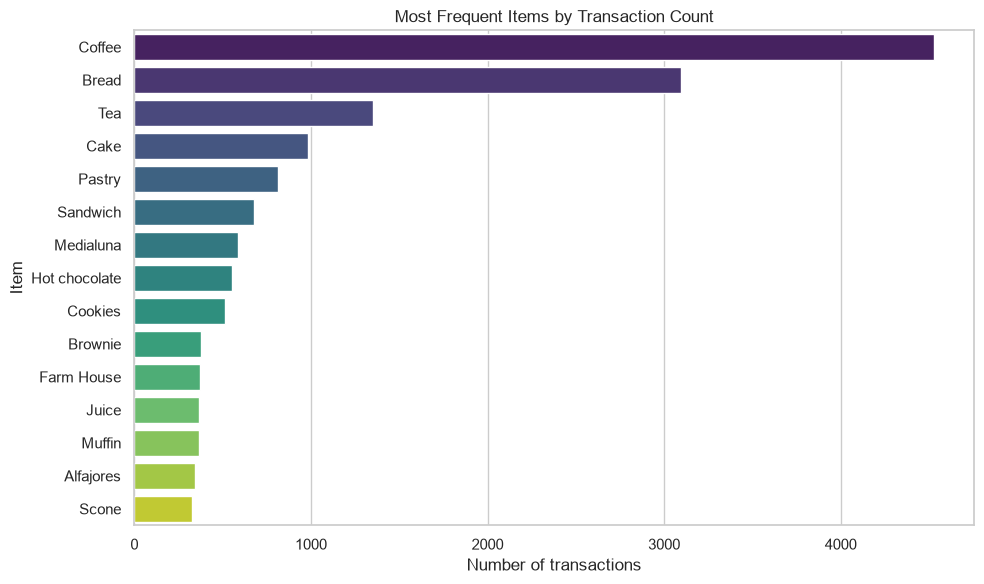

In [4]:
item_counts = clean.drop_duplicates(["Transaction", "Item"])["Item"].value_counts()
top_items = item_counts.head(15).reset_index()
top_items.columns = ["Item", "TransactionCount"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_items, y="Item", x="TransactionCount", hue="Item", palette="viridis", legend=False)
plt.title("Most Frequent Items by Transaction Count")
plt.xlabel("Number of transactions")
plt.ylabel("Item")
plt.tight_layout()
plt.show()


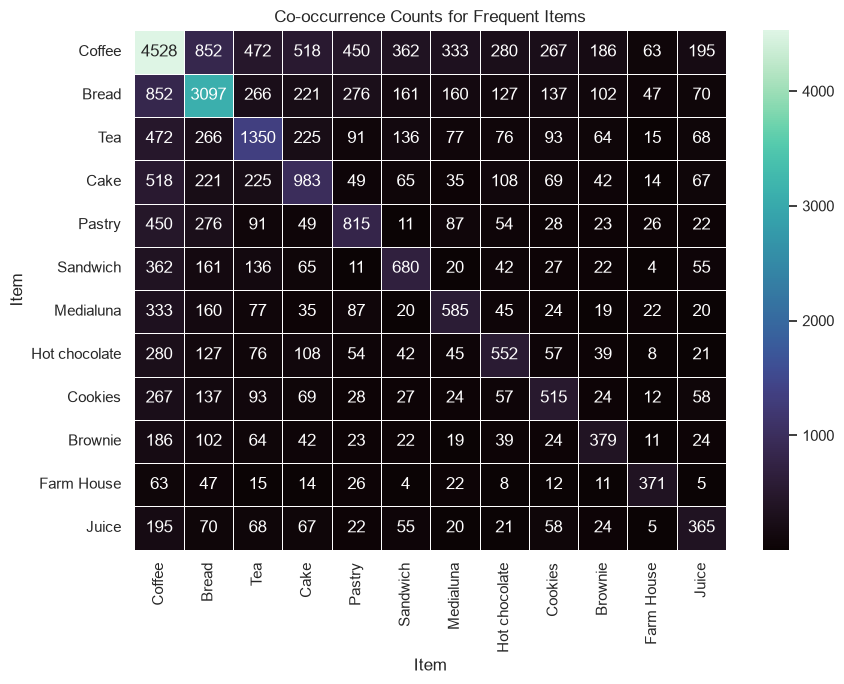

In [5]:
top_heatmap_items = item_counts.head(12).index.tolist()
co_counts = pd.DataFrame(0, index=top_heatmap_items, columns=top_heatmap_items, dtype=int)
for basket in transactions["Items"]:
    basket_set = set(basket)
    for item_a in top_heatmap_items:
        if item_a in basket_set:
            for item_b in top_heatmap_items:
                if item_b in basket_set:
                    co_counts.loc[item_a, item_b] += 1

plt.figure(figsize=(9, 7))
sns.heatmap(co_counts, cmap="mako", annot=True, fmt="d", linewidths=0.4)
plt.title("Co-occurrence Counts for Frequent Items")
plt.xlabel("Item")
plt.ylabel("Item")
plt.tight_layout()
plt.show()


## Step 2: Frequent Itemset Mining with Apriori

The minimum support is set to 1% to keeps common bakery patterns while filtering out rare combinations that would add noise to the rule table.


In [6]:
def support_count(itemset, baskets):
    target = set(itemset)
    return sum(target.issubset(basket) for basket in baskets)


def apriori(transactions_list, min_support=0.01, max_len=3):
    baskets = [set(basket) for basket in transactions_list]
    n_transactions = len(baskets)
    min_count = max(1, int(min_support * n_transactions + 0.999999))

    item_counts = defaultdict(int)
    for basket in baskets:
        for item in basket:
            item_counts[frozenset([item])] += 1

    current = {
        itemset: count
        for itemset, count in item_counts.items()
        if count >= min_count
    }
    all_frequent = dict(current)
    k = 2

    while current and k <= max_len:
        previous_itemsets = list(current.keys())
        candidates = set()
        for left, right in combinations(previous_itemsets, 2):
            union = left | right
            if len(union) == k and all(frozenset(subset) in current for subset in combinations(union, k - 1)):
                candidates.add(union)

        candidate_counts = {}
        for candidate in candidates:
            count = support_count(candidate, baskets)
            if count >= min_count:
                candidate_counts[candidate] = count

        current = candidate_counts
        all_frequent.update(current)
        k += 1

    result = pd.DataFrame(
        [
            {"itemsets": tuple(sorted(itemset)), "support": count / n_transactions, "count": count}
            for itemset, count in all_frequent.items()
        ]
    ).sort_values(["support", "itemsets"], ascending=[False, True], ignore_index=True)
    return result


transaction_lists = transactions["Items"].tolist()
MIN_SUPPORT = 0.01

start = time.perf_counter()
apriori_itemsets = apriori(transaction_lists, min_support=MIN_SUPPORT, max_len=3)
apriori_time = time.perf_counter() - start

apriori_itemsets.head(15)


,itemsets,support,count
0,"(Coffee,)",0.478394,4528
1,"(Bread,)",0.327205,3097
2,"(Tea,)",0.142631,1350
3,"(Cake,)",0.103856,983
4,"(Bread, Coffee)",0.090016,852
5,"(Pastry,)",0.086107,815
6,"(Sandwich,)",0.071844,680
7,"(Medialuna,)",0.061807,585
8,"(Hot chocolate,)",0.058320,552
9,"(Cake, Coffee)",0.054728,518


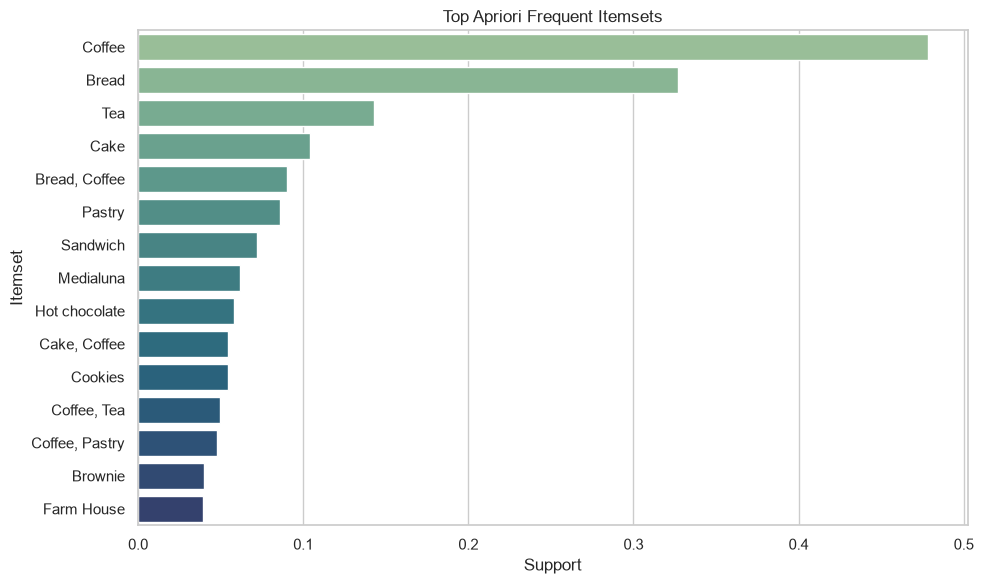

In [7]:
top_apriori = apriori_itemsets.head(15).copy()
top_apriori["Itemset"] = top_apriori["itemsets"].apply(lambda x: ", ".join(x))

plt.figure(figsize=(10, 6))
sns.barplot(data=top_apriori, y="Itemset", x="support", hue="Itemset", palette="crest", legend=False)
plt.title("Top Apriori Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()


## Step 3: Frequent Itemset Mining with FP-Growth

FP-Growth uses the same minimum support. Instead of repeatedly scanning candidate itemsets, it compresses transactions into an FP-tree and mines conditional pattern bases.


In [8]:
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None


def build_fp_tree(weighted_transactions, min_count):
    header_counts = defaultdict(int)
    for items, count in weighted_transactions:
        for item in set(items):
            header_counts[item] += count

    frequent_items = {item: count for item, count in header_counts.items() if count >= min_count}
    if not frequent_items:
        return None, {}

    header = {item: [count, None] for item, count in frequent_items.items()}
    root = FPNode(None, 0, None)

    for items, count in weighted_transactions:
        ordered_items = [
            item for item in sorted(items, key=lambda x: (-frequent_items.get(x, 0), x))
            if item in frequent_items
        ]
        current = root
        for item in ordered_items:
            if item in current.children:
                current.children[item].count += count
            else:
                new_node = FPNode(item, count, current)
                current.children[item] = new_node
                if header[item][1] is None:
                    header[item][1] = new_node
                else:
                    link_node = header[item][1]
                    while link_node.link is not None:
                        link_node = link_node.link
                    link_node.link = new_node
            current = current.children[item]

    return root, header


def prefix_path(node):
    path = []
    parent = node.parent
    while parent is not None and parent.item is not None:
        path.append(parent.item)
        parent = parent.parent
    return list(reversed(path))


def mine_fp_tree(header, min_count, suffix=None):
    suffix = suffix or frozenset()
    frequent = {}
    for item, (count, node) in sorted(header.items(), key=lambda kv: (kv[1][0], kv[0])):
        new_itemset = suffix | frozenset([item])
        frequent[new_itemset] = count

        conditional_transactions = []
        current = node
        while current is not None:
            path = prefix_path(current)
            if path:
                conditional_transactions.append((path, current.count))
            current = current.link

        _, conditional_header = build_fp_tree(conditional_transactions, min_count)
        if conditional_header:
            frequent.update(mine_fp_tree(conditional_header, min_count, new_itemset))
    return frequent


def fp_growth(transactions_list, min_support=0.01, max_len=3):
    n_transactions = len(transactions_list)
    min_count = max(1, int(min_support * n_transactions + 0.999999))
    weighted_transactions = [(list(set(basket)), 1) for basket in transactions_list]
    _, header = build_fp_tree(weighted_transactions, min_count)
    frequent = mine_fp_tree(header, min_count) if header else {}
    result = pd.DataFrame(
        [
            {"itemsets": tuple(sorted(itemset)), "support": count / n_transactions, "count": count}
            for itemset, count in frequent.items()
            if len(itemset) <= max_len
        ]
    ).sort_values(["support", "itemsets"], ascending=[False, True], ignore_index=True)
    return result


start = time.perf_counter()
fpgrowth_itemsets = fp_growth(transaction_lists, min_support=MIN_SUPPORT, max_len=3)
fpgrowth_time = time.perf_counter() - start

fpgrowth_itemsets.head(15)


,itemsets,support,count
0,"(Coffee,)",0.478394,4528
1,"(Bread,)",0.327205,3097
2,"(Tea,)",0.142631,1350
3,"(Cake,)",0.103856,983
4,"(Bread, Coffee)",0.090016,852
5,"(Pastry,)",0.086107,815
6,"(Sandwich,)",0.071844,680
7,"(Medialuna,)",0.061807,585
8,"(Hot chocolate,)",0.058320,552
9,"(Cake, Coffee)",0.054728,518


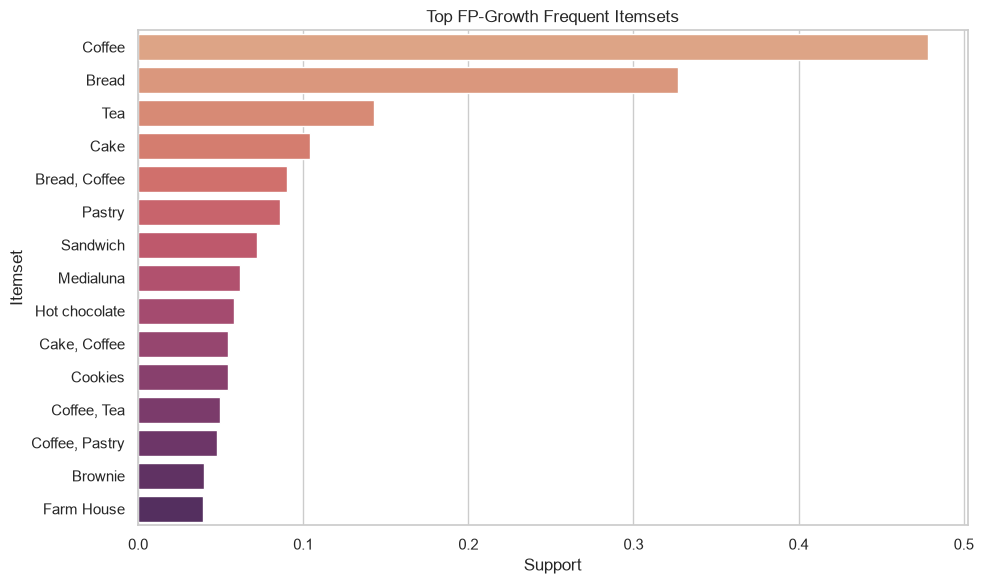

In [9]:
top_fpgrowth = fpgrowth_itemsets.head(15).copy()
top_fpgrowth["Itemset"] = top_fpgrowth["itemsets"].apply(lambda x: ", ".join(x))

plt.figure(figsize=(10, 6))
sns.barplot(data=top_fpgrowth, y="Itemset", x="support", hue="Itemset", palette="flare", legend=False)
plt.title("Top FP-Growth Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()


## Step 4: Generating and Analyzing Association Rules

Rules are generated from the frequent itemsets. The confidence threshold is set to 20% so the analysis keeps rules that occur often enough to interpret while still showing several product relationships.


In [10]:
def generate_rules(frequent_itemsets, min_confidence=0.20):
    support_lookup = {
        frozenset(row.itemsets): row.support
        for row in frequent_itemsets.itertuples(index=False)
    }
    rules = []
    for itemset, support in support_lookup.items():
        if len(itemset) < 2:
            continue
        items = list(itemset)
        for size in range(1, len(items)):
            for antecedent_items in combinations(items, size):
                antecedent = frozenset(antecedent_items)
                consequent = itemset - antecedent
                antecedent_support = support_lookup.get(antecedent)
                consequent_support = support_lookup.get(consequent)
                if not antecedent_support or not consequent_support:
                    continue
                confidence = support / antecedent_support
                if confidence >= min_confidence:
                    rules.append(
                        {
                            "antecedents": tuple(sorted(antecedent)),
                            "consequents": tuple(sorted(consequent)),
                            "support": support,
                            "confidence": confidence,
                            "lift": confidence / consequent_support,
                        }
                    )
    return pd.DataFrame(rules).sort_values(["lift", "confidence", "support"], ascending=False, ignore_index=True)


MIN_CONFIDENCE = 0.20
apriori_rules = generate_rules(apriori_itemsets, min_confidence=MIN_CONFIDENCE)
fpgrowth_rules = generate_rules(fpgrowth_itemsets, min_confidence=MIN_CONFIDENCE)

apriori_rules.head(15)


,antecedents,consequents,support,confidence,lift
0,"(Coffee, Tea)","(Cake,)",0.010037,0.201271,1.937977
1,"(Cake,)","(Tea,)",0.023772,0.228891,1.604781
2,"(Toast,)","(Coffee,)",0.023666,0.704403,1.472431
3,"(Sandwich,)","(Tea,)",0.014369,0.200000,1.402222
4,"(Spanish Brunch,)","(Coffee,)",0.010882,0.598837,1.251766
5,"(Medialuna,)","(Coffee,)",0.035182,0.569231,1.189878
6,"(Pastry,)","(Coffee,)",0.047544,0.552147,1.154168
7,"(Alfajores,)","(Coffee,)",0.019651,0.540698,1.130235
8,"(Juice,)","(Coffee,)",0.020602,0.534247,1.116750
9,"(Sandwich,)","(Coffee,)",0.038246,0.532353,1.112792


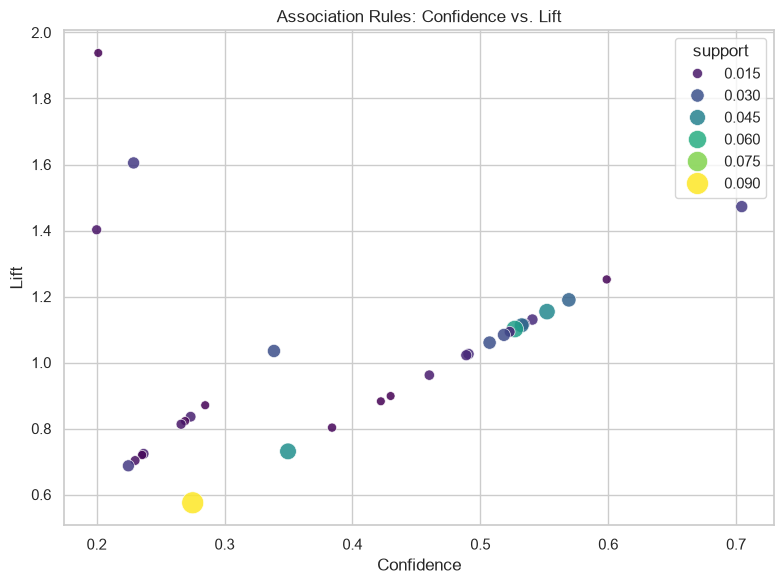

,antecedents,consequents,support,confidence,lift,Rule
0,"(Coffee, Tea)","(Cake,)",0.010037,0.201271,1.937977,"Coffee, Tea -> Cake"
1,"(Cake,)","(Tea,)",0.023772,0.228891,1.604781,Cake -> Tea
2,"(Toast,)","(Coffee,)",0.023666,0.704403,1.472431,Toast -> Coffee
3,"(Sandwich,)","(Tea,)",0.014369,0.200000,1.402222,Sandwich -> Tea
4,"(Spanish Brunch,)","(Coffee,)",0.010882,0.598837,1.251766,Spanish Brunch -> Coffee
5,"(Medialuna,)","(Coffee,)",0.035182,0.569231,1.189878,Medialuna -> Coffee
6,"(Pastry,)","(Coffee,)",0.047544,0.552147,1.154168,Pastry -> Coffee
7,"(Alfajores,)","(Coffee,)",0.019651,0.540698,1.130235,Alfajores -> Coffee
8,"(Juice,)","(Coffee,)",0.020602,0.534247,1.116750,Juice -> Coffee
9,"(Sandwich,)","(Coffee,)",0.038246,0.532353,1.112792,Sandwich -> Coffee


In [11]:
plot_rules = apriori_rules.copy()
plot_rules["Rule"] = plot_rules["antecedents"].apply(lambda x: ", ".join(x)) + " -> " + plot_rules["consequents"].apply(lambda x: ", ".join(x))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_rules,
    x="confidence",
    y="lift",
    size="support",
    hue="support",
    palette="viridis",
    sizes=(40, 250),
    alpha=0.85,
)
plt.title("Association Rules: Confidence vs. Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.tight_layout()
plt.show()

plot_rules.head(10)


The strongest rules point to beverage-and-food pairings. `Toast -> Coffee` has high confidence because toast buyers often also bought coffee. Several pastry or sandwich rules also lead to coffee, which suggests that coffee acts as an anchor product in the bakery baskets. Lift values above 1 show that these items appear together more often than expected if purchases were independent.


## Step 5: Comparative Analysis

The two algorithms are evaluated with the same baskets, support threshold, maximum itemset length, and confidence threshold.


In [12]:
apriori_sets = set(apriori_itemsets["itemsets"])
fpgrowth_sets = set(fpgrowth_itemsets["itemsets"])
comparison = pd.DataFrame(
    {
        "Metric": [
            "Apriori frequent itemsets",
            "FP-Growth frequent itemsets",
            "Shared itemsets",
            "Apriori rules",
            "FP-Growth rules",
            "Apriori runtime seconds",
            "FP-Growth runtime seconds",
        ],
        "Value": [
            len(apriori_itemsets),
            len(fpgrowth_itemsets),
            len(apriori_sets & fpgrowth_sets),
            len(apriori_rules),
            len(fpgrowth_rules),
            round(apriori_time, 4),
            round(fpgrowth_time, 4),
        ],
    }
)
comparison


,Metric,Value
0,Apriori frequent itemsets,61.0000
1,FP-Growth frequent itemsets,61.0000
2,Shared itemsets,61.0000
3,Apriori rules,31.0000
4,FP-Growth rules,31.0000
5,Apriori runtime seconds,0.5909
6,FP-Growth runtime seconds,0.1213


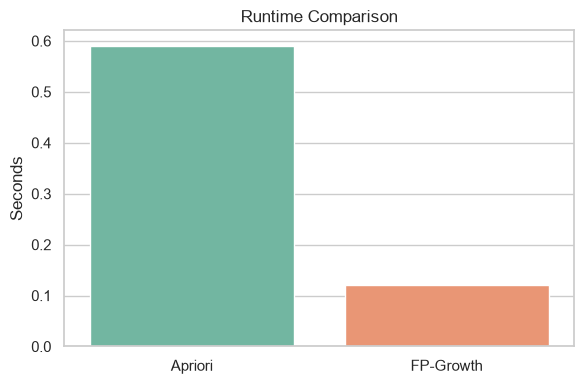

In [13]:
runtime_df = pd.DataFrame(
    {
        "Algorithm": ["Apriori", "FP-Growth"],
        "Seconds": [apriori_time, fpgrowth_time],
    }
)

plt.figure(figsize=(6, 4))
sns.barplot(data=runtime_df, x="Algorithm", y="Seconds", hue="Algorithm", palette="Set2", legend=False)
plt.title("Runtime Comparison")
plt.ylabel("Seconds")
plt.xlabel("")
plt.tight_layout()
plt.show()


Both algorithms returned the same frequent itemsets under the selected threshold. FP-Growth ran faster on this dataset because it compressed transactions into a tree and avoided generating and testing as many candidate itemsets. Apriori was still useful because its candidate-generation process is transparent and easy to verify on a moderate dataset.

The main challenge was choosing a support threshold. A higher threshold returned only broad one-item patterns such as coffee and bread, while a lower threshold produced many sparse combinations. A 1% threshold balanced interpretability with enough two-item and three-item patterns for rule mining.
